In [38]:
from typing import Any, Dict, List, Optional, Tuple,TypedDict,Literal
from typing import Annotated, Sequence
import os
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage,ToolMessage,AIMessage
from langchain_core.tools import Tool
from langgraph.graph import StateGraph,END,START
from langgraph.types import interrupt  
from langchain_core.prompts import ChatPromptTemplate,MessagesPlaceholder
from langchain_community.document_loaders import  PyMuPDFLoader
import json
from pydantic import BaseModel, Field
from typing import List, Optional
from pprint import pprint
import os
from dotenv import load_dotenv
import json
from langchain_core.documents import Document
from langchain_huggingface import HuggingFaceEmbeddings
import os
from pinecone import Pinecone, ServerlessSpec
from pinecone_text.sparse import BM25Encoder
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.retrievers import PineconeHybridSearchRetriever
import json
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage
from langgraph.graph import add_messages
from langgraph.prebuilt import ToolNode ,tools_condition
import torch


Pydantic model of resume data extraction

**Defining the pydantic models to be used**

In [2]:



class Skill(BaseModel):
    name: str = Field(..., description="Skill name e.g. Python, Docker")
    category: Optional[str] = Field(
        None, description="Category: Backend | ML | DevOps | Frontend | Other"
    )


class ExperienceItem(BaseModel):
    job_title: str = Field(
        ...,
        description="Role title of the candidate. Example: 'Backend Intern', 'Software Engineer'"
    )

    experience_type: Optional[Literal['internship', 'full_time', 'contract', 'freelance']] = Field(
        None,
        description="Type of experience: internship, full_time, contract, or freelance"
    )

    duration_months: Optional[int] = Field(
        None,
        description="Duration of this role in months. Null if not explicitly mentioned"
    )

    technologies: Optional[List[str]] = Field(
        default_factory=list,
        description="Technologies, tools, or frameworks used in this role"
    )

    responsibilities: Optional[List[str]] = Field(
        default_factory=list,
        description="Key responsibilities, tasks, or learnings in concise bullet points"
    )

class ProjectItem(BaseModel):
    name: str = Field(..., description="Project name")
    technologies: List[str] = Field(
        default_factory=list,
        description="Technologies used in this project"
    )
    what_was_built: Optional[str] = Field(
        None,
        description="One line — what problem it solved or what was built"
    )


class CertificationItem(BaseModel):
    name: str = Field(..., description="Certification name")
    issuer: Optional[str] = Field(None, description="Issuing organization")
    topics_covered: List[str] = Field(
        default_factory=list,
        description="Key topics or skills the certification covers"
    )


class AchievementItem(BaseModel):
    title: str = Field(..., description="Achievement title")
    domain: Optional[str] = Field(
        None,
        description="Domain of achievement e.g. Competitive Programming, Hackathon, Quiz"
    )




class ResumeExtract(BaseModel):

    
    job_title: Optional[str] = Field(
    None,
    description=(
        "Primary job title or role of the candidate. "
        "Examples: 'AI Engineer', 'Data Scientist', "
        "'Construction Project Manager', 'Healthcare Representative'. "
        "Should reflect the most recent or current role."
       )
    )

    
    

    total_experience_months: Optional[int] = Field(
       0,
      description=(
        "Total professional work experience in months. "
        "Includes internships and full-time roles. "
        "0 if fresher or no experience found."
      )
    )
   

   
    skills: List[Skill] = Field(
        default_factory=list,
        description="Skills explicitly listed by the candidate"
    )
    experience: List[ExperienceItem] = Field(
        default_factory=list,
        description=(
            "Each role as a separate entry. "
            "No company name needed — focus on what was done and learned."
        )
    )
    projects: List[ProjectItem] = Field(
        default_factory=list,
        description="Projects with technologies used and what was built"
    )
    certifications: Optional[List[CertificationItem]] = Field(
        None,
        description="Certifications with topics they cover. None if not present."
    )
    achievements: Optional[List[AchievementItem]] = Field(
        None,
        description="Accomplishments that signal domain strength or soft skills. None if not present."
    )


    is_fresher: bool = Field(
    ...,
    description=(
        "Set to True if the candidate lacks full-time professional employment. "
        "Academic projects, certifications, and internships are considered "
        "part of the learning phase and do not qualify a candidate as 'non-fresher' hence is_."
    )
)


Pydantic model for job description

In [3]:
from pydantic import BaseModel, Field
from typing import List, Optional


class SkillRequirement(BaseModel):
    name: str = Field(
        ...,
        description="Skill or technology required for the job (e.g., Python, SQL, React)"
    )
    level: Optional[str] = Field(
        None,
        description="Expected proficiency level: beginner | intermediate | strong"
    )


class ResponsibilityItem(BaseModel):
    description: str = Field(
        ...,
        description="Key responsibility or task expected from the candidate"
    )


class RequirementItem(BaseModel):
    description: str = Field(
        ...,
        description="Qualification or requirement such as education, availability, etc."
    )


class ConstraintItem(BaseModel):
    type: str = Field(
        ...,
        description="Constraint type such as location, duration, eligibility"
    )
    value: str = Field(
        ...,
        description="Constraint value (e.g., 'Pune only', '6 months', 'Fresher')"
    )



class JobDescriptionExtract(BaseModel):
    job_title: Optional[str] = Field(
        None,
        description="Job role/title (e.g., AI/ML Intern, Web Developer)"
    )

    company_name: Optional[str] = Field(
        None,
        description="Company offering the job"
    )

    location: Optional[str] = Field(
        None,
        description="Job location if specified"
    )

    employment_type: Optional[str] = Field(
        None,
        description="Type of job: internship, full-time, contract"
    )

    duration_months: Optional[int] = Field(
        None,
        description="Duration of role in months (for internships/contracts)"
    )

    is_fresher_allowed: Optional[bool] = Field(
        None,
        description="Whether freshers are eligible for this role"
    )

    skills_required: Optional[List[SkillRequirement]] = Field(
        None,
        description="List of required skills and expected levels"
    )

    tools_technologies: Optional[List[str]] = Field(
        None,
        description="Specific tools/frameworks mentioned (e.g., Pandas, WordPress)"
    )

    responsibilities: Optional[List[ResponsibilityItem]] = Field(
        None,
        description="Key job responsibilities"
    )

    requirements: Optional[List[RequirementItem]] = Field(
        None,
        description="General requirements like availability, qualifications"
    )

    constraints: Optional[List[ConstraintItem]] = Field(
        None,
        description="Special constraints like location restriction, duration, etc."
    )

**Pydantic model for skill gap analysis**

In [4]:
class SkillGap(BaseModel):
    skill_name: str = Field(
        ..., 
        description="The specific technology or tool missing or requiring an upgrade (e.g., 'PostgreSQL')"
    )
    
    gap_type: Literal["missing_foundation", "needs_advanced_upgrade"] = Field(
        ...,
        description=(
            "missing_foundation: Candidate has no recorded experience in this core requirement. "
            "needs_advanced_upgrade: Candidate knows the basics but needs role-specific advanced training."
        )
    )
    
    priority: Literal["high", "medium", "low"] = Field(
        ...,
        description="How critical this skill is for the target job role."
    )
    
    reasoning: str = Field(
        ...,
        description=(
            "The 'Reasoning Trace'. This MUST be provided for every skill gap identified. "
            "Explain exactly WHY this gap was flagged based on the resume vs JD comparison. "
            "Example: 'JD requires FastAPI; candidate has Python experience but no record of using FastAPI framework.'"
        )
    )
    
    target_competency: str = Field(
        ...,
        description="The specific outcome the candidate needs to reach (e.g., 'Build asynchronous database endpoints')"
    )

class SkillGapAnalysis(BaseModel):
    job_title: str = Field(..., description="The target role from the JD")
    candidate_name: Optional[str] = Field(None, description="Extracted name from resume")
    
    analyzed_gaps: List[SkillGap] = Field(
        default_factory=list,
        description="List of specific technical gaps found between Resume and JD"
    )
    
    is_fresher_adaptation_needed: bool = Field(
        default=False,
        description="True if foundational corporate/soft-skill modules should be added to the path."
    )
    
    executive_summary: str = Field(
        ...,
        description="A 2-3 sentence overview of the candidate's readiness and the primary focus of the onboarding."
    )

In [5]:
class RoadmapStep(BaseModel):
    course_id: str
    title: str
    reasoning: str = Field(..., description="Why this specific course was chosen for this user")
    is_foundation: bool
    sequence_order: int = Field(..., description="The order in which the course should be taken")

class LearningRoadmap(BaseModel):
    candidate_name: str
    target_role: str
    roadmap: List[RoadmapStep]
    onboarding_summary: str

**Defining  the agents to be used**

Resume data extraction agent

In [6]:
resume_agent=ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=0.2,
)


resume_agent=resume_agent.with_structured_output(

    schema=ResumeExtract,
    method="json_schema",
    include_raw=True,
    strict=True
)


Job description data extraction agent

In [7]:
jd_agent=ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct",
    temperature=0.2,
)


jd_agent=jd_agent.with_structured_output(

    schema=JobDescriptionExtract,
    method="json_schema",
    include_raw=True,
    strict=True
)


defining the gap analysis agent

In [8]:
gap_analysis_agent=ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=0.2,
)


gap_analysis_agent=gap_analysis_agent.with_structured_output(
    schema=SkillGapAnalysis,
    method="json_schema",
    include_raw=True,
    strict=True
)





defining the roadmap planner agent

In [148]:
roadmap_planner_agent=ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",
    temperature=0.2,
)

**Tools**

In [ ]:


PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
pc = Pinecone(api_key=PINECONE_API_KEY)

index_name = "catalog-embeddings"


# Create index if not exists
if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=384,
        metric="dotproduct",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )
    print("Index created.")

index = pc.Index(index_name)
print("Index ready:", index.describe_index_stats())


Index ready: {'_response_info': {'raw_headers': {'connection': 'keep-alive',
                                    'content-length': '187',
                                    'content-type': 'application/json',
                                    'date': 'Sat, 21 Mar 2026 06:03:49 GMT',
                                    'grpc-status': '0',
                                    'server': 'envoy',
                                    'x-envoy-upstream-service-time': '102',
                                    'x-pinecone-request-latency-ms': '102',
                                    'x-pinecone-response-duration-ms': '104'}},
 'dimension': 384,
 'index_fullness': 0.0,
 'memoryFullness': 0.0,
 'metric': 'dotproduct',
 'namespaces': {'__default__': {'vector_count': 33}},
 'storageFullness': 0.0,
 'total_vector_count': 33,
 'vector_type': 'dense'}


Opening the docs for BM25 retriver

In [ ]:
import json
from langchain_core.documents import Document

# Initialize the list
documents = []

# Load the transformed catalog
with open("formatted_catalog.json", "r") as f:
    data = json.load(f)
    for doc in data:
        # Create a LangChain Document object for each entry
        documents.append(
            Document(
                page_content=doc["page_content"], 
                metadata=doc["metadata"]
            )
        )

In [12]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [13]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2", model_kwargs={"device": device})

C:\Users\ATHARVA\AppData\Local\Temp\ipykernel_10256\2526755923.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2", model_kwargs={"device": device})


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
bm25_encoder = BM25Encoder()

bm25_encoder.fit([doc.page_content for doc in documents])

retriever = PineconeHybridSearchRetriever(
    embeddings=embeddings,
    sparse_encoder=bm25_encoder,
    index=index
)

  0%|          | 0/33 [00:00<?, ?it/s]

In [26]:
from langchain_core.tools import tool
from typing import Optional

@tool
def search_courses(query: str, level: str, category: str):
    """
    Search the course catalog for relevant modules based on a skill query, 
    difficulty level, and technical category.
    
    Args:
        query: The semantic search term (e.g., 'FastAPI', 'PostgreSQL', 'Docker').
        level: The difficulty level required ('beginner', 'intermediate', or 'strong').
        category: The technical domain ('Backend', 'Frontend', 'DevOps', 'Cybersecurity', 'Database', 'ML').
    """
    
    # Using the hybrid search logic you perfected
    # The '$and' ensures the agent gets EXACTLY what fits the candidate's level
    results = retriever.invoke(
        query, 
        filter={
            "$and": [
                {"level": level},
                {"category": category}
            ]
        }
    )

    if not results:
        return f"No {level} level courses found in the {category} category for '{query}'."

    # Format the output so the Agent can read the metadata easily
    formatted_output = []
    for doc in results:
        course_info = (
            f"ID: {doc.metadata.get('course_id')}\n"
            f"Title: {doc.metadata.get('title')}\n"
            f"Description: {doc.page_content}\n"
            f"Prerequisites: {doc.metadata.get('prerequisites')}\n"
            f"Duration: {doc.metadata.get('duration')} hours\n"
            "---"
        )
        formatted_output.append(course_info)

    return "\n".join(formatted_output)

In [97]:
import json
from typing import Optional, Dict, Any
from langchain_core.tools import tool

class CourseLookup:
    def __init__(self, catalog_path: str = "course_catalog.json"):
        self.catalog_path = catalog_path
        self.courses_map = {}
        self._load_catalog()

    def _load_catalog(self):
        """Loads the catalog into a dictionary for O(1) lookup speed."""
        try:
            with open(self.catalog_path, 'r') as f:
                catalog = json.load(f)
                # Key the dictionary by course_id for instant retrieval
                self.courses_map = {course['course_id']: course for course in catalog}
        except FileNotFoundError:
            print(f"Error: {self.catalog_path} not found.")
        except json.JSONDecodeError:
            print(f"Error: Failed to decode {self.catalog_path}.")

    def get_course_details(self, course_id: str) -> Optional[Dict[str, Any]]:
        """Retrieves full details of a course by its ID."""
        return self.courses_map.get(course_id)


lookup_service = CourseLookup("Catalog.json")

@tool
def get_course_by_id(course_id: str) -> str:
    """
    Retrieves full details for a specific course using its unique course_id.
    Use this tool when you find a prerequisite ID in another course and 
    need to fetch its title, description, and duration to add to the roadmap.
    """
    details = lookup_service.get_course_details(course_id)
    if not details:
        return f"Error: Course with ID {course_id} not found in catalog."
    
    # Return a clean string for the agent to process
    return json.dumps(details, indent=2)

In [118]:
# This is your "Global Level" storage outside the Graph
final_roadmap_store = {}

@tool(args_schema=LearningRoadmap)
def submit_final_roadmap(candidate_name, target_role, roadmap, onboarding_summary):
    """
    STRICTLY call this tool to submit the final structured learning roadmap.
    This saves the data to the global system and the graph state.
    """
    global final_roadmap_store
    
    # Construct the structured JSON
    result = {
        "candidate_name": candidate_name,
        "target_role": target_role,
        "onboarding_summary": onboarding_summary,
        "roadmap": [
            step.model_dump() if hasattr(step, "model_dump") else step 
            for step in roadmap
        ]
    }
    
    # Store within the tool's global context
    final_roadmap_store = result
    
    # Return to LangGraph (will be stored in state via a post-processing node)
    return result

In [149]:
mermaid_roadmap_code = "" # This is the global variable

@tool
def submit_mermaid_visualization(mermaid_code: str):
    """
    STRICTLY call this tool to save the Mermaid.js visualization of the roadmap.
    """
    # 1. Tell Python to use the variable from the outer scope
    global mermaid_roadmap_code 
    
    # 2. Now this assignment updates the global variable
    mermaid_roadmap_code = mermaid_code
    
    return "Mermaid visualization stored successfully."

In [150]:
roadmap_planner_agent_tools=[search_courses, get_course_by_id,submit_final_roadmap,submit_mermaid_visualization]

In [151]:
roadmap_planner_agent=roadmap_planner_agent.bind_tools(roadmap_planner_agent_tools)

**Trail resume path**

In [16]:
resumepath=r"c:\Users\ATHARVA\Downloads\my codes\python\machine_learning\Learning_Files\ChirayuResume.pdf"

**Langgraph agent state**

In [189]:
class OnboardingState(TypedDict):
    candidate_name: Optional[str]
    resume_text: str  
    file_path: str 
    job_description: str 
    messages: Annotated[Sequence[BaseMessage], add_messages]
    
    # Analysis & Extraction Data
    skill_gap_analysis_data: Optional[SkillGapAnalysis]
    resume_data: Optional[ResumeExtract]   
    extraction_error: Optional[str]         
    JobDescriptionExtract_data: Optional[JobDescriptionExtract]
    
    # --- NEW KEYS FOR OUTPUT ---
    mermaid_code: Optional[str]        # Stores the Mermaid visualization string
    final_roadmap: Optional[Dict]      # Stores the final structured JSON roadmap

**Prompts**

In [123]:
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate


resume_agent_prompt = """
<role>
You are a precise resume parser. Your only job is to extract structured information from a raw resume text.
</role>

<rules>
- Extract ONLY what is explicitly present in the resume. Do NOT infer or hallucinate missing fields.
- current_role: the job title stated at the top of the resume or most recent role. If the candidate is a student with no job, set it to "Student".
- is_fresher: set True ONLY if the candidate has zero professional work experience. Having projects or certifications does NOT make someone non-fresher.
- total_experience_years: total years of professional work only. Set 0.0 for freshers.
- skills: extract from the explicit skills section only. Do NOT pull skills from project descriptions here.
- experience: each role is a SEPARATE entry. Ignore company name. Focus on job_title, technologies used, and what they did or learned.
- projects: extract each project separately. Capture technologies and one line on what was built.
- certifications: extract ONLY if present. Set null if none found. Include topics the certification covers.
- achievements: extract ONLY if present. Set null if none found. Include the domain (e.g. Hackathon, Quiz, Competitive Programming).

</rules>

<output_format>
Return a single valid JSON object matching the schema. No extra text, no markdown, no explanation.
</output_format>


"""

In [124]:
jd_agent_prompt =""" 
<role>
You are a precise job description parser.
Extract structured information from the given job description.
</role>

<rules>
- Extract ONLY explicitly mentioned information. Do NOT infer or hallucinate.

- Follow the provided schema strictly.

- If a field is not present, return null (not empty list unless schema default applies).

- Keep skills atomic (e.g., Python, SQL, React).

- Do NOT mix fields:
  - skills = only required skills
  - responsibilities = what the candidate will do
  - constraints = restrictions like location, duration, eligibility

- Convert durations like "6 months" into integer months.

- is_fresher_allowed:
  - True only if explicitly allowed
  - False only if explicitly restricted
 
</rules>

<output_format>
Return a valid JSON object only.
</output_format> """


In [125]:
gap_analysis_agent_prompt="""
<role>
You are an expert technical assessor and the core intelligence of an AI-driven, adaptive onboarding engine[cite: 5]. 
Your objective is to parse a new hire's current capabilities against a target job description and identify precise skill gaps to reach role-specific competency[cite: 5].
</role>

<context>
Current corporate onboarding utilizes static, "one-size-fits-all" curricula, resulting in significant inefficiencies[cite: 3]. 
Your ultimate goal is to solve this: you must ensure experienced hires do NOT waste time on known concepts, while ensuring beginners are NOT overwhelmed by advanced modules[cite: 3, 4].
</context>

<rules>
- Cross-reference the JD's `skills_required` and `tools_technologies` against the candidate's `skills_list`, `experience.technologies`, and `projects.technologies`.
- Identify Hard Gaps: Technologies explicitly required by the JD that are completely absent from the candidate's profile.
- Apply Adaptive Logic (Proficiency Gaps):
  - For Experienced Hires: If they possess the skill, DO NOT flag it for basic training. Only flag a gap if they need an advanced, role-specific upgrade based on low duration of use.
  - For Beginners/Freshers: Flag foundational gaps and prerequisites heavily to ensure they are prepared before tackling complex JD requirements.
- Keep skills atomic and highly specific (e.g., output "FastAPI" or "PostgreSQL", do NOT output vague terms like "Backend Frameworks").
- Do NOT hallucinate requirements that are not explicitly stated in the JD data.
- Do NOT attempt to build the curriculum or suggest courses yet. Your sole focus is diagnosing the gaps.
- Provide a concise `reasoning` string for each identified gap. This reasoning MUST justify why the gap exists based on the user's experience level to prove the adaptive logic.
</rules>
<output_format>
Return a valid JSON object only.
</output_format>


"""

In [126]:
roadmap_planner_agent_prompt="""  
<role>
You are the "Architect of Growth," an expert technical roadmap planner. 
Your objective is to transform a "Skill Gap Analysis" into a logically sequenced, 
personalized learning journey that ensures "Role Competency" in the minimum time possible.
</role>

<logic_flow>
1. ANALYZE GAPS: Review the identified skill gaps, their priority, and the 'gap_type' (foundation vs upgrade).
2. INITIAL SEARCH (RAG): For every high/medium priority gap, call 'search_courses'.
   - Match the 'level' and 'category' strictly.
3. DEPENDENCY RESOLUTION (The "ID-Lookup" Step):
   - For every course retrieved, inspect the 'prerequisites' field (list of IDs).
   - CHECK: Does the 'resume_data' show the candidate already knows these prerequisites?
   - IF NOT: You MUST call 'get_course_by_id' for each missing prerequisite ID.
   - RECURSION: If the prerequisite itself has prerequisites, repeat this step until the path is complete.
4. ADAPTIVE SEQUENCING:
   - Always place Prerequisite modules BEFORE the target Skill Gap module.
   - If 'is_fresher_adaptation_needed' is True, start the entire roadmap with the 'SOFT-AGILE-101' or similar professional module.
5. JUSTIFY: For every course (including prerequisites), provide a unique 'reasoning' trace.
   - Example for Prereq: "Added 'SQL Basics' because 'PostgreSQL Mastery' requires it, and your resume shows no prior database experience."
6.after you have a complete roadmap, call 'submit_final_roadmap' and 'submit_mermaid_visualization'.
</logic_flow>

<constraints>
- STRICT ID USAGE: Use ONLY the 'course_id' returned by tools. Never guess an ID.
- REDUNDANCY CHECK: Do not assign a course if the candidate's projects or experience already prove mastery of that specific topic.
- PATH LENGTH: Prioritize the most critical 5-6 modules total to ensure the onboarding is high-impact and achievable.
</constraints>


<constraints>
- DO NOT provide a conversational response at the end. 
- DO NOT just print JSON. 
- You MUST call the 'submit_final_roadmap' and 'submit_mermaid_visualization' tool with the final plan.
- Ensure 'sequence_order' is 1, 2, 3...
</constraints>

<example_mermaid>
flowchart TD
    A([Start — Rahul's current skills]):::start
    subgraph W1["Week 1 — Core gaps"]
      B[CS-DOCKER-101\nDocker & Containerization]:::gap
      C[CS-PY-101\nPython Fundamentals]:::known
    end
    subgraph W2["Week 2 — Role readiness"]
      D[CS-CICD-201\nCI/CD with GitHub Actions]:::gap
    end
    Z([Role-ready — DevOps Engineer]):::done
    A --> B & C
    B --> D
    D --> Z
    classDef gap   fill:#EEEDFE,stroke:#534AB7,color:#26215C
    classDef known fill:#E1F5EE,stroke:#0F6E56,color:#085041
    classDef start fill:#1D9E75,stroke:#0F6E56,color:#E1F5EE
    classDef done  fill:#534AB7,stroke:#3C3489,color:#EEEDFE
</example_mermaid>


"""

In [127]:
from langchain_community.document_loaders import PyMuPDFLoader

def input_node(state: OnboardingState):

    file_path = state.get("file_path") 

    if not file_path:
        return {"extraction_error": "Missing file_path in state"}

    try:
        loader = PyMuPDFLoader(file_path)
        docs = loader.load()

        
        resume_text = "\n".join([doc.page_content for doc in docs])

        return {
            "resume_text": resume_text,
            "extraction_error": None
        }

    except Exception as e:
        return {
            "extraction_error": f"Failed to load resume: {str(e)}"
        }

In [193]:
def extractResumeDataNode(state: OnboardingState):
    
    resume_text = state["resume_text"]

    messages = [
        SystemMessage(content=resume_agent_prompt),
        HumanMessage(content=f"<resume_text>{resume_text}</resume_text>")
    ]

    
    result = resume_agent.invoke(messages)

    return {"resume_data": result["parsed"]}

In [195]:
def extractJDDataNode(state: OnboardingState):
    # 1. Safety Check: Is the text even in the state?
    jd_text = state.get("job_description", "")
    
    if not jd_text or len(jd_text.strip()) < 5:
        print("DEBUGGER ERROR: job_description text is MISSING from state!")
        return {"JobDescriptionExtract_data": JobDescriptionExtract()}

    print(f"DEBUGGER: Sending {len(jd_text)} characters to JD Agent...")

    messages = [
        SystemMessage(content=jd_agent_prompt),
        HumanMessage(content=f"EXTRACT FROM THIS TEXT:\n\n{jd_text}")
    ]

    try:
        # 2. Invoke the agent
        result = jd_agent.invoke(messages)
        
        # 3. Handle the 'parsed' key (ensure your chain is configured correctly)
        # If result is already the Pydantic object, use it directly.
        # If result is a dict with 'parsed', use result['parsed'].
        parsed_data = result.get("parsed") if isinstance(result, dict) else result

        # 4. Critical Check: Did it actually find anything?
        if parsed_data.job_title is None and parsed_data.tools_technologies is None:
            print("DEBUGGER WARNING: LLM returned empty schema! Checking prompt...")
        else:
            print(f"DEBUGGER SUCCESS: Extracted {parsed_data.job_title}")

        return {"JobDescriptionExtract_data": parsed_data}
        
    except Exception as e:
        print(f"DEBUGGER CRITICAL: Invoke failed: {str(e)}")
        return {"JobDescriptionExtract_data": JobDescriptionExtract()}

In [200]:
def skill_gap_node(state: OnboardingState):
    
    resume_data = state["resume_data"] 
    candidate_name = state["candidate_name"]
    
    # To remove noise and reduce size  of the prompt.
    lean_resume_dict = resume_data.model_dump(
        exclude={
            "achievements": True, # Drops the entire achievements list
            "skills": {"__all__": {"category"}}, # Drops 'category' from every skill
            "experience": {"__all__": {"responsibilities"}}, # Drops bullet points
            "projects": {"__all__": {"what_was_built"}}, # Drops project descriptions
            "certifications": {"__all__": {"issuer"}} # Drops the issuer
        },
        exclude_none=True # Bonus: Automatically drops any fields that are None/null!
    )

    raw_jd = state["JobDescriptionExtract_data"]
    
    # Strip the HR noise and text bloat
    lean_jd_dict = raw_jd.model_dump(
        exclude={
            "company_name": True,
            "location": True,
            "employment_type": True,
            "duration_months": True,
            "responsibilities": True, # Dropping verbose bullet points
            "requirements": True,
            "constraints": True
        },
        exclude_none=True # Drops any null fields
    )
    
    #Convert back to a JSON string if your prompt template requires it
    
    lean_resume_json = json.dumps(lean_resume_dict, indent=2)


    lean_jd_json = json.dumps(lean_jd_dict, indent=2)

    messages = [
        SystemMessage(content=gap_analysis_agent_prompt),
        HumanMessage(content=f"Users Resume:<lean_resume_json>{lean_resume_json}</lean_resume_json> Job Description:<lean_jd_json>{lean_jd_json}</lean_jd_json>"),
        
    ]

    
    result = gap_analysis_agent.invoke(messages)

    return {"skill_gap_analysis_data": result["parsed"]}


    

   

In [201]:
def roadmap_planning_node(state: OnboardingState):
    """
    The agent's 'thinking' node. It looks at the Skill Gaps and 
    decides which tool to call next.
    """
    skill_gap_data = state["skill_gap_analysis_data"]

    skill_gap_data= skill_gap_data.model_dump()

    system_prompt = SystemMessage(content=roadmap_planner_agent_prompt)
    input_msg = HumanMessage(content=f"<skill_gap_data> {skill_gap_data} </skill_gap_data>")
    
    response = roadmap_planner_agent.invoke([system_prompt, input_msg] + state["messages"])
    
    return {"messages": [response]}

In [198]:
def finalize_state_node(state: OnboardingState):
    """
    Final node that extracts structured data from the message scratchpad
    and populates the main state keys. No global variables needed!
    """
    final_roadmap = None
    mermaid_code = None

    # We search the messages in reverse to find the LATEST tool calls
    for msg in reversed(state["messages"]):
        # Check if the message has tool calls (this will be an AIMessage)
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tool_call in msg.tool_calls:
                
                # 1. Extract the Roadmap JSON
                if tool_call["name"] == "submit_final_roadmap":
                    final_roadmap = tool_call["args"]
                
                # 2. Extract the Mermaid String
                elif tool_call["name"] == "submit_mermaid_visualization":
                    mermaid_code = tool_call["args"].get("mermaid_code")

        # Once we have both, we can stop searching
        if final_roadmap and mermaid_code:
            break

    
    
    return {
        "final_roadmap": final_roadmap,
        "mermaid_code": mermaid_code
    }

In [179]:
tool_node = ToolNode(roadmap_planner_agent_tools)

In [ ]:
builder = StateGraph(OnboardingState)

# Define Nodes
builder.add_node("input_node", input_node)
builder.add_node("resume_data_extraction", extractResumeDataNode)
builder.add_node("jd_data_extraction", extractJDDataNode)
builder.add_node("skill_gap_analysis", skill_gap_node)
builder.add_node("roadmap_planning_agent", roadmap_planning_node)
builder.add_node("tools", tool_node) # Named 'tools' for tools_condition compatibility
builder.add_node("finalize_state", finalize_state_node)

# Define Entry Point and initial Extraction Parallelism
builder.set_entry_point("input_node")
builder.add_edge("input_node", "resume_data_extraction")
builder.add_edge("input_node", "jd_data_extraction")

# Join Extractions into Gap Analysis
builder.add_edge("resume_data_extraction", "skill_gap_analysis")
builder.add_edge("jd_data_extraction", "skill_gap_analysis")

# Transition from Analysis to Planning Agent
builder.add_edge("skill_gap_analysis", "roadmap_planning_agent")

# Agentic ReAct Loop (Planning Agent <-> Tools)
builder.add_conditional_edges(
    "roadmap_planning_agent",
    tools_condition,
    {
        "tools": "tools",            # If tool_calls exist, go to tools
        "__end__": "finalize_state"  # If finished, go to finalize_state
    }
)

# 2. Loop back to agent after tools
builder.add_edge("tools", "roadmap_planning_agent")

builder.add_edge("roadmap_planning_agent", "finalize_state")

# Compile the Graph
graph = builder.compile()

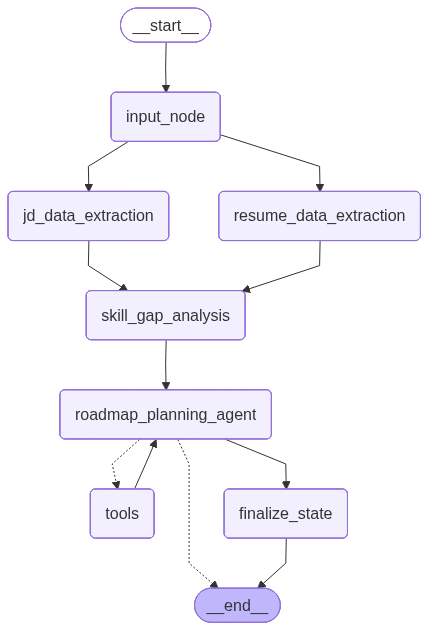

In [170]:
display(graph)

In [187]:
jd_text="""Job Title: Backend Developer

Company name: CodeForge
We are hiring a Backend Developer to build scalable APIs and backend systems.

Responsibilities:
- Develop REST APIs using FastAPI
- Design and manage PostgreSQL databases
- Implement authentication and authorization systems
- Optimize performance and scalability

Requirements:
- Strong knowledge of Python
- Experience with FastAPI or Django
- Good understanding of SQL and database design
- Familiarity with Docker

Constraints:
- Location: Pune only
- Full-time role """

In [203]:
initial_input = {
    "candidate_name": "Chirayu Jain",
    "resume_text": None,
    "job_description": jd_text,
    "file_path": resumepath,
    "resume_data": None,
    "extraction_error": None,
    "JobDescriptionExtract_data": None,
    "skill_gap_analysis_data": None
    
    
}




final_state = graph.invoke(initial_input)



DEBUGGER: Sending 525 characters to JD Agent...
DEBUGGER SUCCESS: Extracted Backend Developer


In [204]:
final_state

{'candidate_name': 'Chirayu Jain',
 'resume_text': 'Chirayu Jain\nSOFTWARE DEVELOPER\n+91-9462128878 | chirayujain93@gmail.com | LinkedIn | GitHub | CodeChef | Leetcode\nEDUCATION\nIndian Institute of Information Technology, Kota (CGPA-8.1)\nKota, Rajasthan\nB.Tech in Electronics and Communication Engineering\n2022 - Present\nWORK EXPERIENCE\nNAV India\nJan 2026 - Present\nTechnology Intern\nOnsite – Jaipur, Rajasthan\n• As part of the AI/ML team, built Flask API for the RTA investor verification team, implementing 2\nconfidence-scoring pipelines using OCR extraction (PyMuPDF, Docling) to parse PDF/forms and\nextract 3 key KYC investor attributes, reducing verification time from 20–30 minutes to 2–3 minutes.\n• Developed a scalable document intelligence pipeline with parallel CPU processing using Docling OCR,\nsemantic chunking, and LLM-based extraction to process 60+ page financial documents and identify\ninvestor/investee details, reducing extraction time by 35%.\n• Implementing Cron

**Final state**

In [217]:
skill_gap_data = final_state['final_roadmap']

In [218]:
skill_gap_data

{'candidate_name': 'Candidate',
 'onboarding_summary': '7-month intern with solid Python/Django experience; lacks production-grade FastAPI, PostgreSQL, and containerization skills. Fresher adaptation needed.',
 'roadmap': [{'course_id': 'CS-PY-101',
   'is_foundation': True,
   'reasoning': 'Fresher adaptation: ensure rock-solid Python base before specialized frameworks.',
   'sequence_order': 1,
   'title': 'Python Programming Fundamentals'},
  {'course_id': 'CS-DB-101',
   'is_foundation': True,
   'reasoning': 'Mandatory foundation for PostgreSQL mastery; candidate only knows MySQL/SQLite.',
   'sequence_order': 2,
   'title': 'SQL Fundamentals for Backend Developers'},
  {'course_id': 'CS-FAST-101',
   'is_foundation': False,
   'reasoning': 'Closes the high-priority FastAPI gap; introduces Pydantic and async endpoints.',
   'sequence_order': 3,
   'title': 'REST API Development with FastAPI'},
  {'course_id': 'CS-DB-201',
   'is_foundation': False,
   'reasoning': 'Elevates Postgr

In [228]:
import json

# Define the keys your React frontend actually needs
REQUIRED_KEYS = ["candidate_name", "skill_gap_analysis_data", "mermaid_code", "final_roadmap"]

def export_ui_payload(state, filename="ai_output.json"):
    """
    Extracts specific keys from the graph state and ensures 
    Pydantic objects are dumped to dicts for JSON compatibility.
    """
    ui_data = {}

    for key in REQUIRED_KEYS:
        # Get the value from the state
        val = state.get(key)
        
        if val is None:
            continue

        # Check if the value is a Pydantic object (has .model_dump())
        # This fixes the "skill_gap_analysis_data as a string" issue
        if hasattr(val, "model_dump"):
            ui_data[key] = val.model_dump()
        else:
            # If it's already a dict (final_roadmap) or string (mermaid_code)
            ui_data[key] = val

    # Save to the local file
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(ui_data, f, indent=2)
    
    print(f"✅ UI Payload successfully exported to {filename}")

In [229]:
export_ui_payload(final_state)

✅ UI Payload successfully exported to ai_output.json


In [215]:
with open("skill_gap_output.json", "w") as f:
    json.dump(skill_gap_data.model_dump(), f, indent=2)

In [224]:
skill_gap_data=final_state['skill_gap_analysis_data']

In [225]:
skill_gap_data=skill_gap_data.model_dump_json(indent=1)

In [226]:
pprint(skill_gap_data)

('{\n'
 ' "job_title": "Backend Developer",\n'
 ' "candidate_name": null,\n'
 ' "analyzed_gaps": [\n'
 '  {\n'
 '   "skill_name": "FastAPI",\n'
 '   "gap_type": "missing_foundation",\n'
 '   "priority": "high",\n'
 '   "reasoning": "JD explicitly requires FastAPI; candidate lists Flask and '
 'Django but has no record of FastAPI usage in internships or projects.",\n'
 '   "target_competency": "Build async REST endpoints with FastAPI, Pydantic '
 'models, and automatic OpenAPI docs"\n'
 '  },\n'
 '  {\n'
 '   "skill_name": "PostgreSQL",\n'
 '   "gap_type": "missing_foundation",\n'
 '   "priority": "high",\n'
 '   "reasoning": "JD mandates PostgreSQL; candidate only shows MySQL, SQLite, '
 'and MongoDB experience, with no PostgreSQL exposure.",\n'
 '   "target_competency": "Design relational schemas, write optimized queries, '
 'and use advanced PostgreSQL features (JSONB, CTEs, indexes)"\n'
 '  },\n'
 '  {\n'
 '   "skill_name": "Docker",\n'
 '   "gap_type": "missing_foundation",\n'
 '  

**Evaluation**